# Cafe Sales — Data Cleaning Notebook
**Dataset:** `dirty_cafe_sales.csv` — 10,000 giao dịch quán cà phê

**Mục tiêu:** Phát hiện, phân tích và làm sạch dữ liệu để sẵn sàng cho phân tích doanh thu.

> Mỗi bước xử lý gồm **(1) Markdown giải thích lý do** và **(2) Code thực thi**.

## 0. Cài thư viện & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 60)

df_raw = pd.read_csv('dirty_cafe_sales.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 1. Tổng quan Dataset

Trước khi xử lý bất kỳ thứ gì, cần có bức tranh toàn cảnh:
- Dataset có bao nhiêu hàng/cột?
- Mỗi cột có kiểu dữ liệu gì?
- Có bao nhiêu giá trị null?

In [2]:
print('=== dtypes ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
miss = df_raw.isnull().sum()
pct  = (miss / len(df_raw) * 100).round(2)
print(pd.DataFrame({'count': miss, 'pct_%': pct}))

=== dtypes ===
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

=== Missing Values ===
                  count  pct_%
Transaction ID        0   0.00
Item                333   3.33
Quantity            138   1.38
Price Per Unit      179   1.79
Total Spent         173   1.73
Payment Method     2579  25.79
Location           3265  32.65
Transaction Date    159   1.59


### Quan sát ban đầu

**Vấn đề dtype:** Tất cả 8 cột đều là `object` (string), trong khi:
- `Quantity`, `Price Per Unit`, `Total Spent` → nên là `float`/`int`
- `Transaction Date` → nên là `datetime`

**Hậu quả nếu không sửa:** `df['Total Spent'].mean()` sẽ lỗi hoặc trả về kết quả sai.

**Missing values đáng chú ý:**
- `Location`: 32.65% — rất cao
- `Payment Method`: 25.79% — cao
- Các cột còn lại: < 4% — chấp nhận được

## 2. Phát hiện chi tiết từng vấn đề

### Vấn đề 1 — Giá trị `ERROR` và `UNKNOWN` giả làm dữ liệu thực

Ngoài null thực sự, dataset còn chứa các chuỗi `"ERROR"` và `"UNKNOWN"` được nhập vào
thay vì để trống. Đây là **dạng null ẩn** nguy hiểm nhất — pandas không tự nhận ra,
dẫn đến khi convert sang số sẽ tạo NaN không kiểm soát được.

In [3]:
# Kiểm tra giá trị unique từng cột để phát hiện ERROR/UNKNOWN
for col in df_raw.columns:
    vals = df_raw[col].unique()
    junk = [v for v in vals if str(v).upper() in {'ERROR', 'UNKNOWN'}]
    count = df_raw[col].isin(junk).sum() if junk else 0
    if junk:
        print(f'{col:25s} → junk values: {junk} | count: {count}')

Item                      → junk values: ['UNKNOWN', 'ERROR'] | count: 636
Quantity                  → junk values: ['ERROR', 'UNKNOWN'] | count: 341
Price Per Unit            → junk values: ['ERROR', 'UNKNOWN'] | count: 354
Total Spent               → junk values: ['ERROR', 'UNKNOWN'] | count: 329
Payment Method            → junk values: ['UNKNOWN', 'ERROR'] | count: 599
Location                  → junk values: ['UNKNOWN', 'ERROR'] | count: 696
Transaction Date          → junk values: ['ERROR', 'UNKNOWN'] | count: 301


### Vấn đề 2 — Tất cả cột số đang là string

Khi dataset chứa `ERROR`/`UNKNOWN`, pandas buộc phải đọc cột số là `object`.
Cần làm sạch các giá trị rác trước, rồi mới convert được sang `float`.

In [4]:
# Thử convert ngay mà không làm sạch trước → xem kết quả
test = pd.to_numeric(df_raw['Quantity'], errors='coerce')
print(f'Quantity null sau to_numeric (chưa làm sạch): {test.isnull().sum()}')
print('→ Pandas tạo NaN ngầm cho ERROR/UNKNOWN mà không báo lỗi!')
print(f'  (null thực: {df_raw["Quantity"].isnull().sum()}, tổng sau convert: {test.isnull().sum()})')

Quantity null sau to_numeric (chưa làm sạch): 479
→ Pandas tạo NaN ngầm cho ERROR/UNKNOWN mà không báo lỗi!
  (null thực: 138, tổng sau convert: 479)


### Vấn đề 3 — Kiểm tra tính nhất quán: Total Spent = Quantity × Price Per Unit

Nếu `Total Spent` luôn bằng `Quantity × Price Per Unit`, ta có thể **impute ngược**:
biết 2 trong 3 giá trị → tính được giá trị còn lại.

Đây là bước EDA quan trọng — xác nhận business rule trước khi viết code impute.

In [6]:
# Kiểm tra business rule: Total = Qty × Price
df_check = df_raw.copy()
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df_check[col] = pd.to_numeric(df_check[col], errors='coerce')

df_check['calc_total'] = df_check['Quantity'] * df_check['Price Per Unit']
df_check['mismatch']   = abs(df_check['calc_total'] - df_check['Total Spent']) > 0.01

verifiable = df_check.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent'])
print(f'Hàng có thể kiểm tra: {len(verifiable):,}')
print(f'Mismatch:              {df_check["mismatch"].sum()}')
print()
print('Total Spent = Quantity × Price Per Unit luôn đúng!')
print('→ Có thể impute an toàn khi biết 2 trong 3 giá trị.')

Hàng có thể kiểm tra: 8,544
Mismatch:              0

Total Spent = Quantity × Price Per Unit luôn đúng!
→ Có thể impute an toàn khi biết 2 trong 3 giá trị.


### Vấn đề 4 — Mỗi Item có đúng 1 mức giá cố định

Nếu đúng như vậy, biết `Item` → suy ra được `Price Per Unit` chắc chắn 100%.
Đây là loại imputation **độ tin cậy cao nhất** (lookup, không phải ước tính thống kê).

In [7]:
# Kiểm tra: mỗi Item có bao nhiêu mức giá?
item_price = (
    df_check[df_check['Item'].notna() & ~df_check['Item'].isin(['ERROR','UNKNOWN'])]
    .groupby('Item')['Price Per Unit']
    .agg(['mean', 'min', 'max', 'nunique'])
)
print(item_price)
print()
print('nunique = 1 cho tất cả Item hợp lệ → mỗi item có đúng 1 giá cố định!')

          mean  min  max  nunique
Item                             
Cake       3.0  3.0  3.0        1
Coffee     2.0  2.0  2.0        1
Cookie     1.0  1.0  1.0        1
Juice      3.0  3.0  3.0        1
Salad      5.0  5.0  5.0        1
Sandwich   4.0  4.0  4.0        1
Smoothie   4.0  4.0  4.0        1
Tea        1.5  1.5  1.5        1

nunique = 1 cho tất cả Item hợp lệ → mỗi item có đúng 1 giá cố định!


## 3. Bảng tổng hợp vấn đề & quyết định xử lý

| # | Vấn đề | Cột bị ảnh hưởng | Mức độ | Quyết định |
|---|--------|-----------------|--------|------------|
| 1 | Giá trị `"ERROR"` và `"UNKNOWN"` ẩn | Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location | Critical | Thay bằng NaN tường minh |
| 2 | Missing values thực (Location 32%, Payment 25%) | Location, Payment Method | Critical | `fillna('Unknown')` — tỷ lệ quá cao để drop |
| 3 | Tất cả cột số là string (object) | Quantity, Price Per Unit, Total Spent | Critical | `pd.to_numeric` sau bước 1 |
| 4 | Transaction Date là string | Transaction Date | Minor | `pd.to_datetime` |
| 5 | Total Spent có thể impute từ Qty × Price | Total Spent | Minor | Tính lại bằng công thức |
| 6 | Price Per Unit impute được từ Item | Price Per Unit | Minor | Lookup từ item_price_map |
| 7 | Hàng không có Date hoặc Total Spent | Transaction Date, Total Spent | Critical | Drop (483 hàng) |

---

### Quyết định khó: Location và Payment Method (25–32% null)

**Phương án 1: Drop các hàng null**
- Dataset sạch hoàn toàn
- Mất 3,000–4,000 hàng (~30% data) — quá nhiều, ảnh hưởng lớn đến phân tích doanh thu

**Phương án 2: Impute bằng mode (giá trị phổ biến nhất)**
- Giữ được data
- Không có bằng chứng rằng null phân phối giống mode — tạo bias giả tạo

**Phương án 3: fillna('Unknown') ← Chọn phương án này**
- Giữ hàng, không tạo giả định sai
- Phân tích downstream tự quyết định có lọc nhóm 'Unknown' không
- Nhóm 'Unknown' lớn có thể gây nhiễu nếu không lọc khi phân tích

## 4. Pipeline làm sạch — hàm `clean_cafe_data()`

In [13]:
# Mapping giá cố định theo item — xác nhận từ EDA bước 2
ITEM_PRICE_MAP = {
    'Coffee'  : 2.0,
    'Tea'     : 1.5,
    'Cookie'  : 1.0,
    'Cake'    : 3.0,
    'Juice'   : 3.0,
    'Sandwich': 4.0,
    'Smoothie': 4.0,
    'Salad'   : 5.0,
}

def clean_cafe_data(df_input):
    """
    Pipeline làm sạch dirty_cafe_sales.csv.

    Parameters
    ----------
    df_input : pd.DataFrame
        Raw dataframe đọc trực tiếp từ CSV.

    Returns
    -------
    df : pd.DataFrame
        DataFrame đã làm sạch, không sửa in-place.

    Các bước:
        1. ERROR/UNKNOWN → NaN
        2. Convert numeric cols sang float
        3. Convert Transaction Date sang datetime
        4. Impute Price Per Unit từ Item (lookup)
        5. Impute Total Spent = Qty × Price
        6. Impute Quantity = Total / Price (chỉ nếu kết quả là số nguyên)
        7. fillna Location và Payment Method → 'Unknown'
        8. fillna Item → 'Unknown'
        9. Drop hàng không thể phục hồi (null Date hoặc Total Spent)
        10. Convert Quantity sang Int64
    """
    df = df_input.copy()

    # ── Bước 1: ERROR / UNKNOWN → NaN ────────────────────────────────────
    # LÝ DO: Đây là null ẩn. Thay tường minh trước khi convert dtype
    # để kiểm soát chính xác bao nhiêu giá trị bị mất.
    JUNK = {'ERROR', 'UNKNOWN', 'error', 'unknown', 'N/A', ''}
    for col in df.columns:
        df[col] = df[col].replace(list(JUNK), np.nan)

    # ── Bước 2: Convert cột số sang float ────────────────────────────────
    # LÝ DO: Sau bước 1, các cột này chỉ còn số hợp lệ và NaN
    # → to_numeric an toàn, không tạo NaN bất ngờ
    for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Bước 3: Transaction Date → datetime ──────────────────────────────
    # LÝ DO: Format YYYY-MM-DD đã nhất quán, chỉ cần convert
    # để dùng được .dt.year, .dt.month trong phân tích chuỗi thời gian
    df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

    # ── Bước 4: Impute Price Per Unit từ Item ─────────────────────────────
    # LÝ DO: EDA xác nhận mỗi Item có đúng 1 mức giá cố định (nunique=1)
    # Đây là imputation độ tin cậy 100% — lookup, không phải ước tính
    mask_price = df['Price Per Unit'].isnull() & df['Item'].notna()
    df.loc[mask_price, 'Price Per Unit'] = df.loc[mask_price, 'Item'].map(ITEM_PRICE_MAP)

    # ── Bước 5: Impute Total Spent = Quantity × Price Per Unit ────────────
    # LÝ DO: EDA xác nhận công thức luôn đúng (0 mismatch trong 8,544 hàng)
    # → Impute bằng công thức là chính xác tuyệt đối
    mask_total = df['Total Spent'].isnull() & df['Quantity'].notna() & df['Price Per Unit'].notna()
    df.loc[mask_total, 'Total Spent'] = (
        df.loc[mask_total, 'Quantity'] * df.loc[mask_total, 'Price Per Unit']
    )

    # ── Bước 6: Impute Quantity = Total Spent / Price Per Unit ────────────
    # LÝ DO: Quantity phải là số nguyên dương (không thể order 2.7 ly cà phê)
    # Chỉ nhận kết quả nếu phép chia cho ra số nguyên, tránh tạo dữ liệu sai
    mask_qty = df['Quantity'].isnull() & df['Total Spent'].notna() & df['Price Per Unit'].notna()
    calc_qty = df.loc[mask_qty, 'Total Spent'] / df.loc[mask_qty, 'Price Per Unit']
    valid_qty = calc_qty[calc_qty == calc_qty.round(0)]
    df.loc[valid_qty.index, 'Quantity'] = valid_qty

    # ── Bước 7: Location và Payment Method → 'Unknown' ────────────────────
    # LÝ DO: Tỷ lệ null quá cao (25–32%) để drop — sẽ mất ~30% dữ liệu
    # Không có cơ sở impute → giữ hàng, đánh dấu 'Unknown'
    # Phân tích downstream có thể filter nhóm này nếu cần
    df['Location']       = df['Location'].fillna('Unknown')
    df['Payment Method'] = df['Payment Method'].fillna('Unknown')

    # ── Bước 8: Item → 'Unknown' ──────────────────────────────────────────
    # LÝ DO: Không thể suy ra Item từ thông tin khác
    # Giữ hàng vì Total Spent vẫn hợp lệ → có giá trị cho phân tích doanh thu
    df['Item'] = df['Item'].fillna('Unknown')

    # ── Bước 9: Drop hàng không thể phục hồi ─────────────────────────────
    # LÝ DO: Hàng không có Transaction Date → vô dụng cho phân tích theo thời gian
    #        Hàng không có Total Spent (sau tất cả imputation) → không đóng góp
    #        gì cho phân tích doanh thu. Drop là quyết định hợp lý.
    before = len(df)
    df = df.dropna(subset=['Transaction Date', 'Total Spent']).reset_index(drop=True)
    print(f'[Bước 9] Drop {before - len(df)} hàng không thể phục hồi')

    # ── Bước 10: Quantity → Int64 ─────────────────────────────────────────
    # LÝ DO: Quantity là số nguyên (số món), Int64 hỗ trợ NaN (khác với int64)
    df['Quantity'] = df['Quantity'].round(0).astype('Int64')

    return df

## 5. Chạy pipeline & kiểm tra kết quả

Sau khi định nghĩa hàm, chạy trên data thực và xem kết quả từng chỉ số.

In [14]:
df_clean = clean_cafe_data(df_raw)

print('=' * 55)
print('SO SÁNH TRƯỚC / SAU')
print('=' * 55)
print(f'Shape gốc : {df_raw.shape}')
print(f'Shape sạch: {df_clean.shape}')
print(f'Hàng bị drop: {df_raw.shape[0] - df_clean.shape[0]}')
print()

# Bảng so sánh null trước / sau
null_before = df_raw.isnull().sum()
null_after  = df_clean.isnull().sum()
compare = pd.DataFrame({'null_trước': null_before, 'null_sau': null_after})
compare['đã xử lý'] = compare['null_trước'] - compare['null_sau']
print('--- Null trước / sau ---')
print(compare)
print()

print('--- dtypes sau cleaning ---')
print(df_clean.dtypes)

[Bước 9] Drop 483 hàng không thể phục hồi
SO SÁNH TRƯỚC / SAU
Shape gốc : (10000, 8)
Shape sạch: (9517, 8)
Hàng bị drop: 483

--- Null trước / sau ---
                  null_trước  null_sau  đã xử lý
Transaction ID             0         0         0
Item                     333         0       333
Quantity                 138         3       135
Price Per Unit           179        48       131
Total Spent              173         0       173
Payment Method          2579         0      2579
Location                3265         0      3265
Transaction Date         159         0       159

--- dtypes sau cleaning ---
Transaction ID                 str
Item                           str
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [10]:
print('--- Location ---')
print(df_clean['Location'].value_counts())
print()
print('--- Payment Method ---')
print(df_clean['Payment Method'].value_counts())
print()
print('--- Item ---')
print(df_clean['Item'].value_counts())
print()
print('--- Total Spent stats ---')
print(df_clean['Total Spent'].describe().round(2))

--- Location ---
Location
Unknown     3771
Takeaway    2883
In-store    2863
Name: count, dtype: int64

--- Payment Method ---
Payment Method
Unknown           3006
Digital Wallet    2191
Credit Card       2166
Cash              2154
Name: count, dtype: int64

--- Item ---
Item
Juice       1121
Coffee      1118
Salad       1097
Cake        1081
Sandwich    1071
Smoothie    1046
Cookie      1033
Tea         1026
Unknown      924
Name: count, dtype: int64

--- Total Spent stats ---
count    9517.00
mean        8.92
std         6.01
min         1.00
25%         4.00
50%         8.00
75%        12.00
max        25.00
Name: Total Spent, dtype: float64


## 6. Kiểm tra trực quan sau cleaning

Vẽ nhanh một số biểu đồ để xác nhận data đã hợp lý.

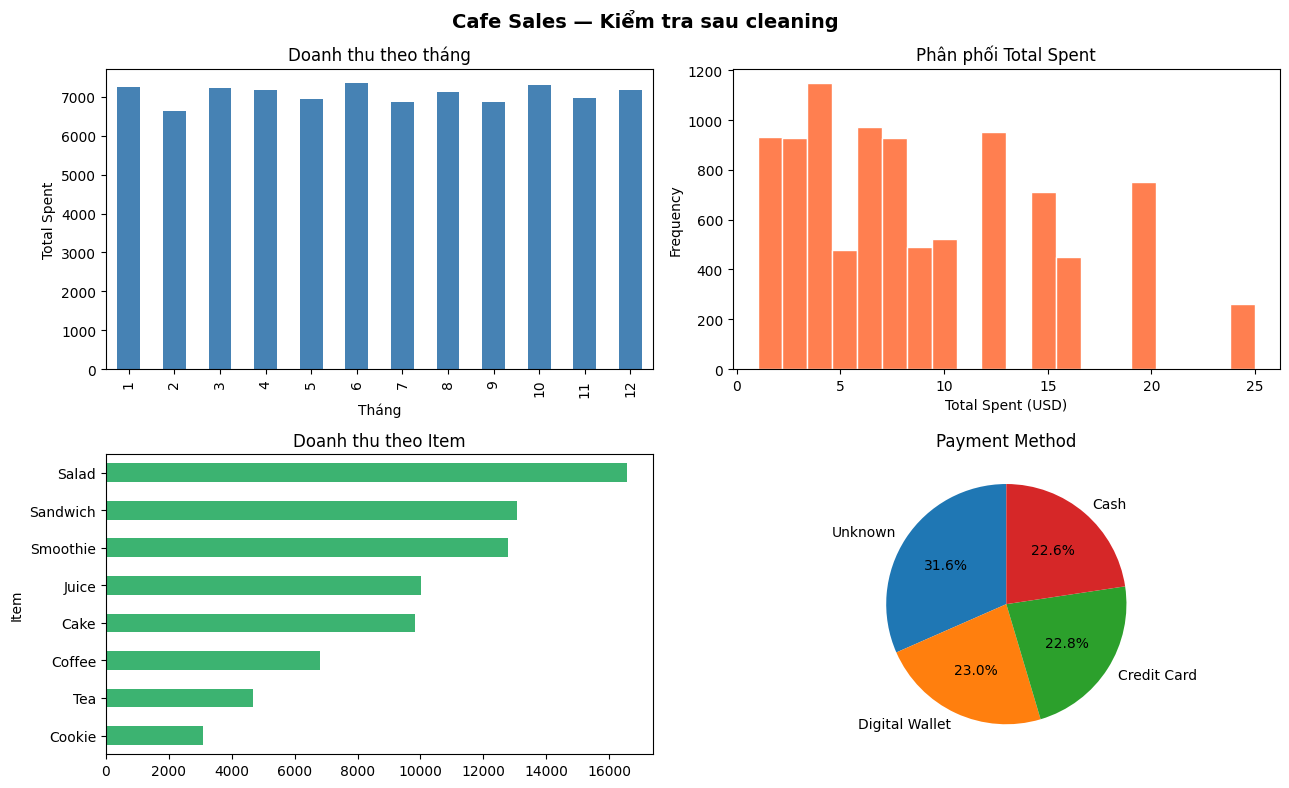

Đã lưu cafe_cleaning_charts.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Cafe Sales — Kiểm tra sau cleaning', fontsize=14, fontweight='bold')

# 1. Doanh thu theo tháng
monthly = df_clean.groupby(df_clean['Transaction Date'].dt.month)['Total Spent'].sum()
monthly.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Doanh thu theo tháng')
axes[0,0].set_xlabel('Tháng'); axes[0,0].set_ylabel('Total Spent')

# 2. Phân phối Total Spent
df_clean['Total Spent'].plot(kind='hist', bins=20, ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Phân phối Total Spent')
axes[0,1].set_xlabel('Total Spent (USD)')

# 3. Doanh thu theo Item
item_rev = df_clean[df_clean['Item'] != 'Unknown'].groupby('Item')['Total Spent'].sum().sort_values()
item_rev.plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Doanh thu theo Item')

# 4. Payment Method
df_clean['Payment Method'].value_counts().plot(kind='pie', ax=axes[1,1],
    autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Payment Method')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('cafe_cleaning_charts.png', dpi=100)
plt.show()
print('Đã lưu cafe_cleaning_charts.png')

## 7. Unit Tests — Kiểm tra pipeline tự động

Unit test đảm bảo pipeline hoạt động đúng nếu chạy lại trên dữ liệu mới.

In [17]:
def test_pipeline(df_in, df_out):
    """Kiểm tra các điều kiện bất biến sau clean_cafe_data()."""

    # Test 1: Số hàng giảm hoặc bằng (không tăng)
    assert df_out.shape[0] <= df_in.shape[0], 'FAIL: rows tăng!'
    assert df_out.shape[0] > 0, 'FAIL: DataFrame rỗng!'
    print('Test 1 PASS: shape hợp lệ')

    # Test 2: Không còn ERROR / UNKNOWN gốc trong bất kỳ cột nào
    # LƯU Ý: so sánh exact string, KHÔNG dùng .str.upper() vì
    # 'Unknown' (ta tự điền) khác với 'UNKNOWN' (giá trị rác gốc)
    JUNK_EXACT = {'ERROR', 'UNKNOWN', 'error', 'unknown'}
    for col in df_out.columns:
        vals = set(df_out[col].dropna().astype(str).unique())
        junk_found = vals & JUNK_EXACT
        assert not junk_found, f'FAIL: còn {junk_found} trong {col}'
    print('Test 2 PASS: không còn ERROR/UNKNOWN')

    # Test 3: dtype đúng
    assert pd.api.types.is_float_dtype(df_out['Total Spent']), 'FAIL: Total Spent không phải float'
    assert pd.api.types.is_datetime64_any_dtype(df_out['Transaction Date']), 'FAIL: Date không phải datetime'
    print('Test 3 PASS: dtype đúng')

    # Test 4: Total Spent không âm
    assert (df_out['Total Spent'] >= 0).all(), 'FAIL: Total Spent có giá trị âm'
    print('Test 4 PASS: Total Spent không âm')

    # Test 5: Không còn null ở Transaction Date và Total Spent
    assert df_out['Transaction Date'].isnull().sum() == 0, 'FAIL: Date vẫn còn null'
    assert df_out['Total Spent'].isnull().sum() == 0, 'FAIL: Total Spent vẫn còn null'
    print('Test 5 PASS: Transaction Date và Total Spent không còn null')

    # Test 6: Total Spent nhất quán với Qty × Price (với hàng có đủ dữ liệu)
    check = df_out.dropna(subset=['Quantity', 'Price Per Unit'])
    calc  = check['Quantity'].astype(float) * check['Price Per Unit']
    mismatch = (abs(calc - check['Total Spent']) > 0.01).sum()
    assert mismatch == 0, f'FAIL: {mismatch} hàng Total Spent sai'
    print('Test 6 PASS: Total Spent = Quantity × Price Per Unit')

    print()
    print('Tất cả unit tests PASSED!')

test_pipeline(df_raw, df_clean)

Test 1 PASS: shape hợp lệ
Test 2 PASS: không còn ERROR/UNKNOWN
Test 3 PASS: dtype đúng
Test 4 PASS: Total Spent không âm
Test 5 PASS: Transaction Date và Total Spent không còn null
Test 6 PASS: Total Spent = Quantity × Price Per Unit

Tất cả unit tests PASSED!


## 8. Export dataset đã làm sạch

Lưu kết quả ra file CSV để sử dụng trong các bước phân tích tiếp theo.

In [18]:
df_clean.to_csv('cafe_sales_cleaned.csv', index=False)
print(f'Đã lưu cafe_sales_cleaned.csv — shape: {df_clean.shape}')
print()
print('5 hàng đầu của dataset sạch:')
df_clean.head()

Đã lưu cafe_sales_cleaned.csv — shape: (9517, 8)

5 hàng đầu của dataset sạch:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## 9. Tóm tắt — Bảng so sánh Trước / Sau

| Chỉ số | Trước | Sau |
|--------|-------|-----|
| Số hàng | 10,000 | **9,517** (drop 483 hàng không phục hồi được) |
| Null `Total Spent` | 337 | **0** (impute bằng Qty × Price) |
| Null `Transaction Date` | 159 | **0** (drop hàng) |
| Null `Location` | 3,265 (32%) | **0** (fillna 'Unknown') |
| Null `Payment Method` | 2,579 (25%) | **0** (fillna 'Unknown') |
| `ERROR`/`UNKNOWN` còn lại | ~2,000 | **0** |
| dtype `Total Spent` | object | **float64** |
| dtype `Transaction Date` | object | **datetime64** |
| dtype `Quantity` | object | **Int64** |

### Hạn chế còn lại

- **Location 'Unknown' chiếm ~39%** của dataset sạch — khi phân tích theo địa điểm cần lọc nhóm này ra.
- **Payment Method 'Unknown' chiếm ~31%** — tương tự.
- **Item 'Unknown'** (~3%) — không thể phân tích doanh thu theo mặt hàng cho nhóm này.
- **Quantity còn 3 null, Price Per Unit còn 48 null** — các hàng này có Item là 'Unknown' nên không impute được.